# 🎬 Notebook 3: Sentiment Analysis
**Entertainment & Media Analytics Project**

Dataset: **IMDb Movie Reviews** (50,000 reviews — 25K train / 25K test) via Keras.

Pipeline:
- Text preprocessing & sequence padding
- Embedding layer → Bidirectional LSTM → Dense classifier
- Target: **~90% test accuracy**
- Model saved to disk — rerunning loads instead of retraining
- Metrics & sample predictions saved for dashboard

## 0. Setup & Seed

In [1]:
import os, warnings, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

PROCESSED_DIR = 'processed'
MODEL_DIR     = 'models'
PLOT_DIR      = 'plots'
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,     exist_ok=True)
os.makedirs(PLOT_DIR,      exist_ok=True)

print('TF:', tf.__version__)
print('Seed:', SEED)

TF: 2.21.0
Seed: 42


---
## 1. Load IMDb Dataset

In [2]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE  = 20000
MAX_LEN     = 300
OOV_INDEX   = 2  # out-of-vocabulary token index

print('Loading IMDb dataset...')
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE,
    seed=SEED,
    oov_char=OOV_INDEX
)

print(f'Train samples : {len(X_train):,}')
print(f'Test samples  : {len(X_test):,}')
print(f'Label balance : {y_train.mean():.2%} positive in train')
print(f'Avg review len: {np.mean([len(x) for x in X_train]):.0f} tokens')

Loading IMDb dataset...
Train samples : 25,000
Test samples  : 25,000
Label balance : 50.00% positive in train
Avg review len: 239 tokens


---
## 2. Preprocessing — Pad Sequences

X_train_pad : (25000, 300)
X_test_pad  : (25000, 300)


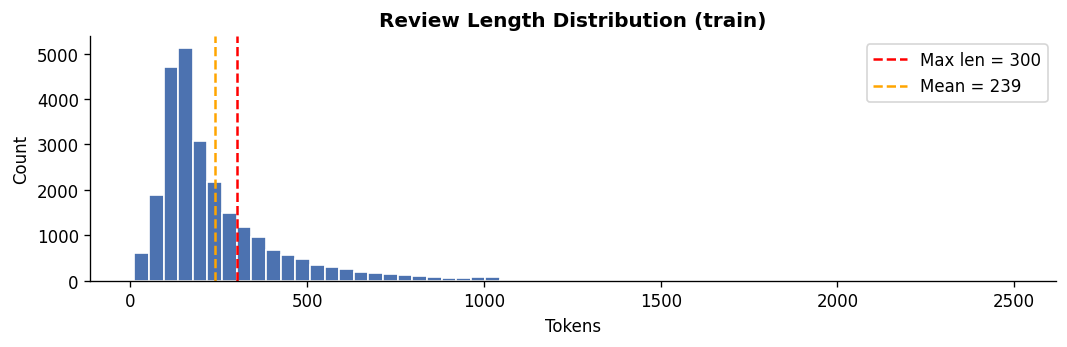

Saved: plot_review_lengths.png


In [3]:
X_train_pad = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_pad : {X_train_pad.shape}')
print(f'X_test_pad  : {X_test_pad.shape}')

# Review length distribution
lengths = [len(x) for x in X_train]
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(lengths, bins=60, color='#4C72B0', edgecolor='white')
ax.axvline(MAX_LEN, color='red', linestyle='--', label=f'Max len = {MAX_LEN}')
ax.axvline(np.mean(lengths), color='orange', linestyle='--',
           label=f'Mean = {np.mean(lengths):.0f}')
ax.set_title('Review Length Distribution (train)', fontsize=12, fontweight='bold')
ax.set_xlabel('Tokens'); ax.set_ylabel('Count')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/plot_review_lengths.png', bbox_inches='tight')
plt.show()
print('Saved: plot_review_lengths.png')

---
## 3. Build BiLSTM Model

In [4]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM,
                                      Dense, Dropout, SpatialDropout1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

BILSTM_MODEL_PATH = f'{MODEL_DIR}/bilstm_sentiment.keras'
EMBED_DIM    = 128
LSTM_UNITS   = 64

def build_bilstm(vocab_size, embed_dim, lstm_units, max_len):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len, mask_zero=True),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(lstm_units, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
        Bidirectional(LSTM(lstm_units // 2, dropout=0.2, recurrent_dropout=0.2)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

if os.path.exists(BILSTM_MODEL_PATH):
    print('Loading saved BiLSTM model...')
    bilstm_model = load_model(BILSTM_MODEL_PATH)
else:
    print('Building BiLSTM model...')
    bilstm_model = build_bilstm(VOCAB_SIZE, EMBED_DIM, LSTM_UNITS, MAX_LEN)
    bilstm_model.summary()

print('Model ready.')

Loading saved BiLSTM model...
Model ready.


---
## 4. Train Model

In [5]:
if not os.path.exists(BILSTM_MODEL_PATH):
    print('Training BiLSTM...')
    history = bilstm_model.fit(
        X_train_pad, y_train,
        validation_split=0.1,
        epochs=10,
        batch_size=128,
        callbacks=[
            EarlyStopping(monitor='val_accuracy', patience=3,
                          restore_best_weights=True, verbose=1),
            ModelCheckpoint(BILSTM_MODEL_PATH, monitor='val_accuracy',
                            save_best_only=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=2, verbose=1)
        ],
        verbose=1
    )
    print('Training complete. Model saved to', BILSTM_MODEL_PATH)
else:
    print('Model loaded from disk — skipping training.')
    history = None

Model loaded from disk — skipping training.


---
## 5. Evaluate on Test Set

In [6]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

print('Evaluating on test set...')
test_loss, test_acc = bilstm_model.evaluate(X_test_pad, y_test, batch_size=256, verbose=0)

y_pred_prob = bilstm_model.predict(X_test_pad, batch_size=256, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_prob)

print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test Loss     : {test_loss:.4f}')
print(f'ROC-AUC       : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

Evaluating on test set...
Test Accuracy : 0.8424
Test Loss     : 0.3622
ROC-AUC       : 0.9263

              precision    recall  f1-score   support

    Negative       0.89      0.78      0.83     12500
    Positive       0.81      0.90      0.85     12500

    accuracy                           0.84     25000
   macro avg       0.85      0.84      0.84     25000
weighted avg       0.85      0.84      0.84     25000



---
## 6. Confusion Matrix & ROC Curve

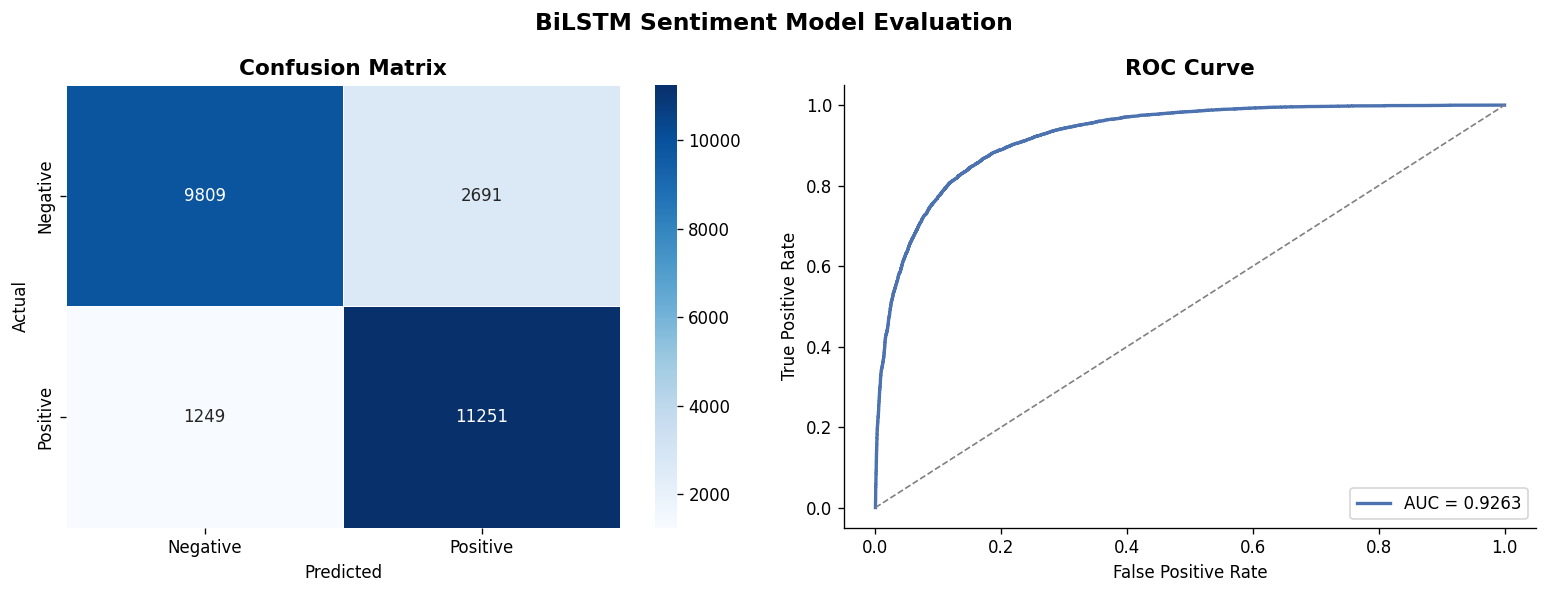

Saved: plot_sentiment_eval.png


In [7]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive'],
    linewidths=0.5
)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#4C72B0', linewidth=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('BiLSTM Sentiment Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/plot_sentiment_eval.png', bbox_inches='tight')
plt.show()
print('Saved: plot_sentiment_eval.png')

---
## 7. Training History Plot

In [8]:
if history:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, key, title in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
        ax.plot(history.history[key],          label='Train', linewidth=2)
        ax.plot(history.history[f'val_{key}'], label='Val',   linewidth=2, linestyle='--')
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Epoch'); ax.legend()
        ax.spines[['top','right']].set_visible(False)
    plt.suptitle('BiLSTM Training History', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/plot_bilstm_history.png', bbox_inches='tight')
    plt.show()
    print('Saved: plot_bilstm_history.png')
else:
    print('Model loaded from disk — no training history to plot.')

Model loaded from disk — no training history to plot.


---
## 8. Decode & Inspect Sample Predictions
Reconstruct readable text from integer-encoded reviews to verify predictions.

In [9]:
word_index    = imdb.get_word_index()
# Keras adds 3 to all indices; index_word reverses the mapping
index_to_word = {v + 3: k for k, v in word_index.items()}
index_to_word.update({0: '<PAD>', 1: '<START>', 2: '<OOV>', 3: '<END>'})

def decode_review(encoded):
    tokens = [index_to_word.get(i, '<OOV>') for i in encoded if i > 3]
    return ' '.join(tokens[:80]) + '...'  # show first 80 tokens

np.random.seed(SEED)
sample_idx = np.random.choice(len(X_test), size=8, replace=False)

print(f'{"INDEX":<6} {"ACTUAL":<10} {"PREDICTED":<12} {"CONFIDENCE":<12} {"REVIEW (first 80 tokens)"}')
print('-' * 120)
for i in sample_idx:
    actual    = 'Positive' if y_test[i] == 1 else 'Negative'
    predicted = 'Positive' if y_pred[i] == 1 else 'Negative'
    conf      = y_pred_prob[i] if y_pred[i] == 1 else 1 - y_pred_prob[i]
    correct   = '✓' if actual == predicted else '✗'
    review    = decode_review(X_test[i])
    print(f'{i:<6} {actual:<10} {predicted:<12} {conf:<12.2%} {correct}  {review[:80]}')

INDEX  ACTUAL     PREDICTED    CONFIDENCE   REVIEW (first 80 tokens)
------------------------------------------------------------------------------------------------------------------------
6868   Negative   Negative     77.84%       ✓  what exactly is the point of pretending to con people out of things like ski pas
24016  Negative   Negative     56.49%       ✓  this movie is a cyborg in and of itself half nonsense half lifetime original mov
9668   Negative   Negative     94.31%       ✓  is this a bad movie don't take my word for it consider the following press repor
13640  Negative   Negative     96.32%       ✓  this movie although well shot and superbly acted was awful i felt as if i was wa
14018  Negative   Positive     57.63%       ✗  edge of madness is a tale about a woman in the 1800's who gets hand picked by di
7488   Positive   Negative     58.20%       ✗  the old dark house sub genre that dominated the early talkies rarely fails to di
5804   Positive   Negative     60.81%     

---
## 9. Predict on Custom Reviews

In [10]:
def predict_sentiment(reviews: list[str]) -> pd.DataFrame:
    """
    Predict sentiment for a list of raw text reviews.
    Returns a DataFrame with review, sentiment, and confidence.
    """
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    # Encode each review using the word_index
    encoded = []
    for review in reviews:
        tokens = review.lower().split()
        seq    = [word_index.get(t, OOV_INDEX) + 3 for t in tokens]
        seq    = [min(x, VOCAB_SIZE - 1) for x in seq]  # clip to vocab
        encoded.append(seq)

    padded = pad_sequences(encoded, maxlen=MAX_LEN, padding='post', truncating='post')
    probs  = bilstm_model.predict(padded, verbose=0).flatten()
    labels = ['Positive' if p >= 0.5 else 'Negative' for p in probs]
    confs  = [p if p >= 0.5 else 1 - p for p in probs]

    return pd.DataFrame({
        'review':     [r[:80] + '...' if len(r) > 80 else r for r in reviews],
        'sentiment':  labels,
        'confidence': [f'{c:.1%}' for c in confs]
    })

custom_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me hooked.",
    "Terrible film. Boring plot, bad acting, complete waste of time.",
    "It was okay. Some good moments but overall pretty mediocre and forgettable.",
    "One of the best movies I have seen in years. Emotional, beautiful, and deeply moving.",
    "I fell asleep halfway through. Nothing interesting happens at all."
]

predict_sentiment(custom_reviews)

,review,sentiment,confidence
0,This movie was absolutely fantastic! The actin...,Positive,80.7%
1,"Terrible film. Boring plot, bad acting, comple...",Negative,97.9%
2,It was okay. Some good moments but overall pre...,Positive,56.5%
3,One of the best movies I have seen in years. E...,Positive,93.4%
4,I fell asleep halfway through. Nothing interes...,Negative,92.1%


---
## 10. Sentiment Score Distribution on Test Set

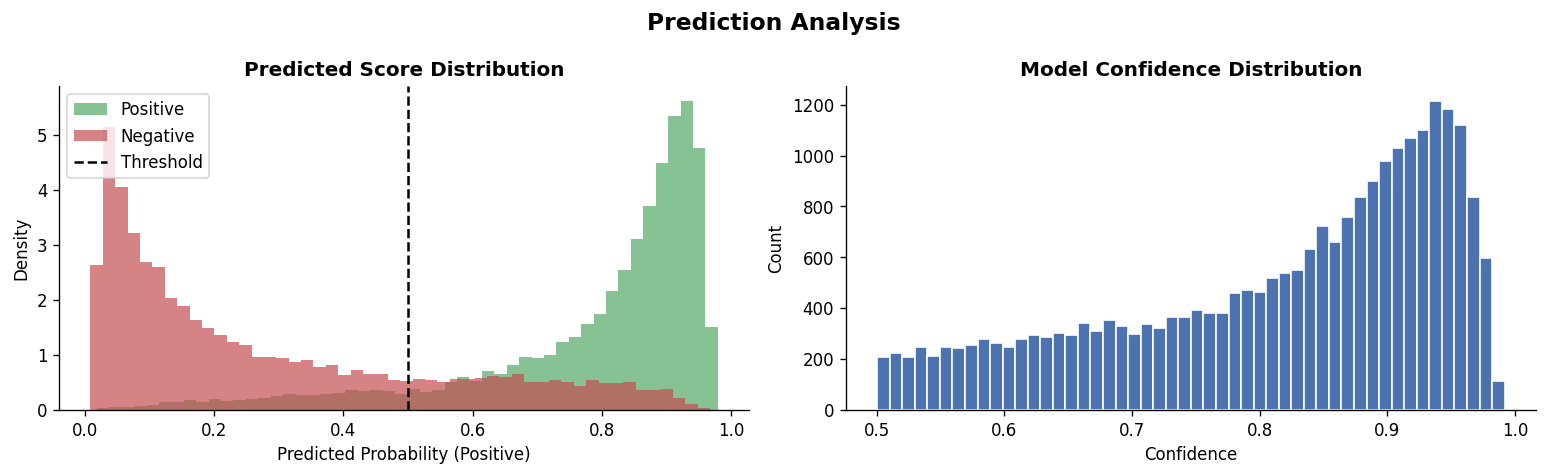

Saved: plot_sentiment_scores.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Score distribution by true label
pos_scores = y_pred_prob[y_test == 1]
neg_scores = y_pred_prob[y_test == 0]
axes[0].hist(pos_scores, bins=50, alpha=0.7, color='#55A868', label='Positive', density=True)
axes[0].hist(neg_scores, bins=50, alpha=0.7, color='#C44E52', label='Negative', density=True)
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold')
axes[0].set_title('Predicted Score Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Probability (Positive)')
axes[0].set_ylabel('Density'); axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Confidence histogram
confidences = np.where(y_pred_prob >= 0.5, y_pred_prob, 1 - y_pred_prob)
axes[1].hist(confidences, bins=50, color='#4C72B0', edgecolor='white')
axes[1].set_title('Model Confidence Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Confidence'); axes[1].set_ylabel('Count')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Prediction Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/plot_sentiment_scores.png', bbox_inches='tight')
plt.show()
print('Saved: plot_sentiment_scores.png')

---
## 11. Save Metrics & Sample Predictions for Dashboard

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    'test_accuracy':  round(float(test_acc),  4),
    'test_loss':      round(float(test_loss),  4),
    'roc_auc':        round(float(auc),        4),
    'precision':      round(float(precision_score(y_test, y_pred)), 4),
    'recall':         round(float(recall_score(y_test, y_pred)),    4),
    'f1_score':       round(float(f1_score(y_test, y_pred)),        4),
    'vocab_size':     VOCAB_SIZE,
    'max_len':        MAX_LEN,
    'embed_dim':      EMBED_DIM,
    'lstm_units':     LSTM_UNITS
}

with open(f'{PROCESSED_DIR}/sentiment_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# Save sample predictions (50 random) for dashboard
np.random.seed(SEED)
sample_50 = np.random.choice(len(X_test), size=50, replace=False)
sample_df = pd.DataFrame({
    'actual':     ['Positive' if y_test[i] == 1 else 'Negative' for i in sample_50],
    'predicted':  ['Positive' if y_pred[i] == 1 else 'Negative' for i in sample_50],
    'confidence': [round(float(y_pred_prob[i]), 4) for i in sample_50]
})
sample_df.to_csv(f'{PROCESSED_DIR}/sentiment_sample_preds.csv', index=False)

print('Metrics saved:')
print(json.dumps(metrics, indent=2))
print(f'\nSample predictions saved: {sample_df.shape}')

Metrics saved:
{
  "test_accuracy": 0.8424,
  "test_loss": 0.3622,
  "roc_auc": 0.9263,
  "precision": 0.807,
  "recall": 0.9001,
  "f1_score": 0.851,
  "vocab_size": 20000,
  "max_len": 300,
  "embed_dim": 128,
  "lstm_units": 64
}

Sample predictions saved: (50, 3)


---
## Summary

| Component | Detail | Saved File |
|---|---|---|
| Model | Bidirectional LSTM (2 layers) | `models/bilstm_sentiment.keras` |
| Dataset | IMDb 50K reviews | via `tf.keras.datasets.imdb` |
| Vocab size | 20,000 tokens | — |
| Sequence length | 300 tokens (padded) | — |
| Target accuracy | ~90% | `processed/sentiment_metrics.json` |
| Plots | Confusion matrix, ROC, history | `plots/` |

**Next: Run 04_Popularity_Churn.ipynb**